In [1]:
import pyPLUTO as pp
from matplotlib import pyplot as plt
from tqdm import tqdm
import numpy as np

PyPLUTO version: 1.0   session: Jupyter notebook or qtconsole


# 3A) Compare the growth of instabilities for the roe and hll Solvers. 
- Visualize the tracer quantity tr1 as an animation for both solvers.
- Reconfiguration and recompilation via setup.py and the .ini file work analogously to Exercise 5.2.
- Calculate the global quantity $\int v_{y}^{2}\ dV$ (see the provided JuPyter notebook) and visualize its evolution over time.

### roe Riemann Solver

In [2]:
# Load data in your output folder
D = pp.Load('all', vars = True, datatype = 'flt', path="/dartfs-hpc/rc/home/s/f005d7s/hw5/p3/c/roe/")

Load: folder /dartfs-hpc/rc/home/s/f005d7s/hw5/p3/c/roe/,     output [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200]


In [4]:
# Select a specific time frame (index 112) of tracer variable tr1

intervals = np.linspace(0, 200, num=201, dtype=int)

for interval in intervals:
    data = D.tr1[interval]

    # Create a figure and axis with a tall aspect ratio
    fig, ax = plt.subplots(figsize=(6, 8.5))

    # Plot 2D data using a colored mesh
    pcm = ax.pcolormesh(
        D.x1, D.x2, data.T,   # Grid coordinates in x and y; transpose data to match axis orientation
        shading='auto',       # Automatically choose flat or nearest shading to avoid warnings
        cmap='bone'           # Grayscale-style colormap
    )

    # Label axes and control plot geometry
    ax.set_title('Time Frame of tr1:    {}'.format(interval))
    ax.set_xlabel('x')        # Horizontal spatial coordinate
    ax.set_ylabel('y')        # Vertical spatial coordinate
    ax.set_aspect('equal')    # Ensure equal scaling in x and y (no distortion)
    ax.set_ylim([-0.5, 0.5])  # Restrict visible y-range to zoom into region of interest

    # Add a colorbar with fine control over its size and spacing
    cbar = fig.colorbar(
        pcm, ax=ax,
        label='Tracer',       # Colorbar label
        fraction=0.03,        # Relative width of the colorbar compared to the plot
        pad=0.05              # Gap between plot and colorbar
    )

    plt.savefig('c_plots/roe/{}.png'.format(interval), dpi=300)
    plt.close()

100%|██████████| 200/200 [00:00<00:00, 371.98it/s]


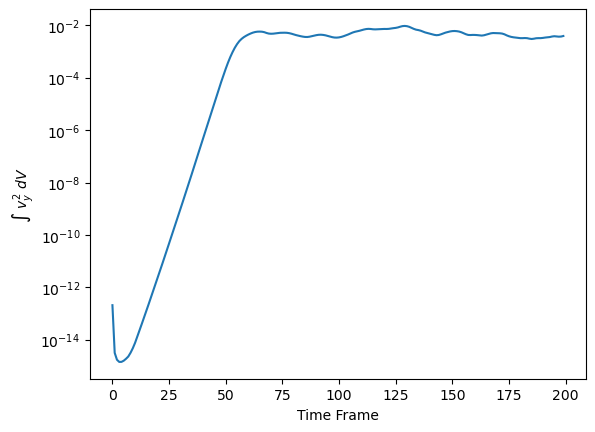

In [5]:
# Initialize list to store volume-integrated transverse velocity energy vs time
vperp = []

# Loop over simulation output steps (0 through 200)
for step in tqdm(range(0, 200)):
    data = D.vx2[step]**2  # Square of transverse velocity component (v_y^2)

    # Integrate over the full simulation volume:
    # sum over all grid cells × cell volume (dx * dy * dz)
    vperp.append(np.sum(data) * D.dx1[0] * D.dx2[0] * D.dx3[0])

# Convert to NumPy array for easier analysis and plotting
vperp = np.array(vperp)

# Plot time evolution of the integrated perpendicular kinetic energy proxy
plt.plot(vperp)

# Use logarithmic scale to better show growth/decay over orders of magnitude
plt.yscale('log')

plt.xlabel('Time Frame')
plt.ylabel(r'$ \int \ v_{y}^{2} \ dV $')
plt.savefig('roe_vy2_c',dpi=300)

### hll Riemann Solver

In [6]:
# Load data in your output folder
D = pp.Load('all', vars = True, datatype = 'flt', path="/dartfs-hpc/rc/home/s/f005d7s/hw5/p3/c/hll/")

Load: folder /dartfs-hpc/rc/home/s/f005d7s/hw5/p3/c/hll/,     output [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200]


In [7]:
# Select a specific time frame (index 112) of tracer variable tr1

intervals = np.linspace(0, 200, num=201, dtype=int)

for interval in intervals:
    data = D.tr1[interval]

    # Create a figure and axis with a tall aspect ratio
    fig, ax = plt.subplots(figsize=(6, 8.5))

    # Plot 2D data using a colored mesh
    pcm = ax.pcolormesh(
        D.x1, D.x2, data.T,   # Grid coordinates in x and y; transpose data to match axis orientation
        shading='auto',       # Automatically choose flat or nearest shading to avoid warnings
        cmap='bone'           # Grayscale-style colormap
    )

    # Label axes and control plot geometry
    ax.set_title('Time Frame of tr1:    {}'.format(interval))
    ax.set_xlabel('x')        # Horizontal spatial coordinate
    ax.set_ylabel('y')        # Vertical spatial coordinate
    ax.set_aspect('equal')    # Ensure equal scaling in x and y (no distortion)
    ax.set_ylim([-0.5, 0.5])  # Restrict visible y-range to zoom into region of interest

    # Add a colorbar with fine control over its size and spacing
    cbar = fig.colorbar(
        pcm, ax=ax,
        label='Tracer',       # Colorbar label
        fraction=0.03,        # Relative width of the colorbar compared to the plot
        pad=0.05              # Gap between plot and colorbar
    )

    plt.savefig('c_plots/hll/{}.png'.format(interval), dpi=300)
    plt.close()

100%|██████████| 200/200 [00:00<00:00, 450.80it/s]


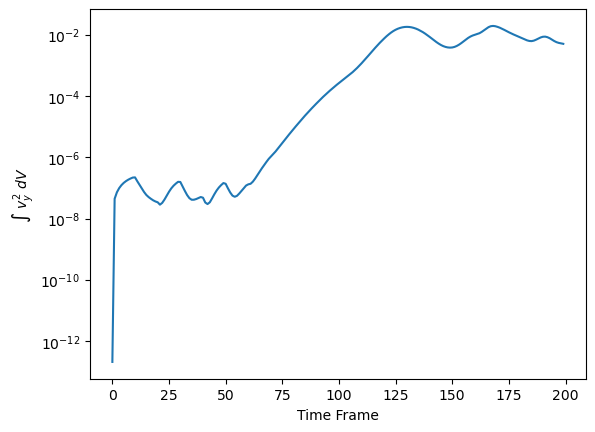

In [8]:
# Initialize list to store volume-integrated transverse velocity energy vs time
vperp = []

# Loop over simulation output steps (0 through 200)
for step in tqdm(range(0, 200)):
    data = D.vx2[step]**2  # Square of transverse velocity component (v_y^2)

    # Integrate over the full simulation volume:
    # sum over all grid cells × cell volume (dx * dy * dz)
    vperp.append(np.sum(data) * D.dx1[0] * D.dx2[0] * D.dx3[0])

# Convert to NumPy array for easier analysis and plotting
vperp = np.array(vperp)

# Plot time evolution of the integrated perpendicular kinetic energy proxy
plt.plot(vperp)

# Use logarithmic scale to better show growth/decay over orders of magnitude
plt.yscale('log')

plt.xlabel('Time Frame')
plt.ylabel(r'$ \int \ v_{y}^{2} \ dV $')
plt.savefig('hll_vy2_c',dpi=300)